In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier 
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support, 
                             confusion_matrix, classification_report)
from sklearn.preprocessing import LabelEncoder



In [2]:
#load data

print("Loading Dataset")
train_df = pd.read_csv("KDDTrain.csv")
test_df = pd.read_csv("KDDTest.csv")

Loading Dataset


In [3]:
cols_to_drop = ['difficulty_level'] 
train_df = train_df.drop(columns=[c for c in cols_to_drop if c in train_df.columns])
test_df = test_df.drop(columns=[c for c in cols_to_drop if c in test_df.columns])

In [4]:
X_train_raw = train_df.drop(columns=['attack_type'])
y_train_raw = train_df['attack_type']
X_test_raw = test_df.drop(columns=['attack_type'])
y_test_raw = test_df['attack_type']

In [5]:
combined_X = pd.concat([X_train_raw, X_test_raw], axis=0)
combined_X_encoded = pd.get_dummies(combined_X)


In [6]:
X_train = combined_X_encoded.iloc[:len(train_df)]
X_test = combined_X_encoded.iloc[len(train_df):]

In [7]:
le = LabelEncoder()
all_labels = pd.concat([y_train_raw, y_test_raw])
le.fit(all_labels)

LabelEncoder()

In [8]:
y_train = le.transform(y_train_raw)
y_test = le.transform(y_test_raw)
class_names = le.classes_

In [9]:
print("Training Hybrid Model (XGBoost + LightGBM)...")

xgb_model = XGBClassifier(
    n_estimators=100, 
    learning_rate=0.1, 
    max_depth=6, 
    eval_metric='mlogloss',
    random_state=42
)

lgbm_model = LGBMClassifier(
    n_estimators=100, 
    learning_rate=0.1, 
    max_depth=6, 
    random_state=42,
    verbose=-1
)

Training Hybrid Model (XGBoost + LightGBM)...


In [10]:
hybrid_model = VotingClassifier(
    estimators=[('xgb', xgb_model), ('lgbm', lgbm_model)],
    voting='soft'
)

hybrid_model.fit(X_train, y_train)

,estimators,"[('xgb', ...), ('lgbm', ...)]"
,voting,'soft'
,weights,None
,n_jobs,None
,flatten_transform,True
,verbose,False
,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None


In [11]:
print("Evaluating model...")
y_pred = hybrid_model.predict(X_test)

# Calculate metrics with zero_division=0 to fix the warning
accuracy = accuracy_score(y_test, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(
    y_test, 
    y_pred, 
    average='weighted', 
    zero_division=0
)

Evaluating model...


In [12]:
metrics_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Score': [accuracy, precision, recall, f1]
})

print("\n--- Performance Metrics ---")
print(metrics_df.to_string(index=False))


--- Performance Metrics ---
   Metric    Score
 Accuracy 0.598696
Precision 0.397952
   Recall 0.598696
 F1-Score 0.476098


C:\Users\saadr\AppData\Local\Temp\ipykernel_24908\1792858069.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Metric', y='Score', data=metrics_df, palette='viridis')


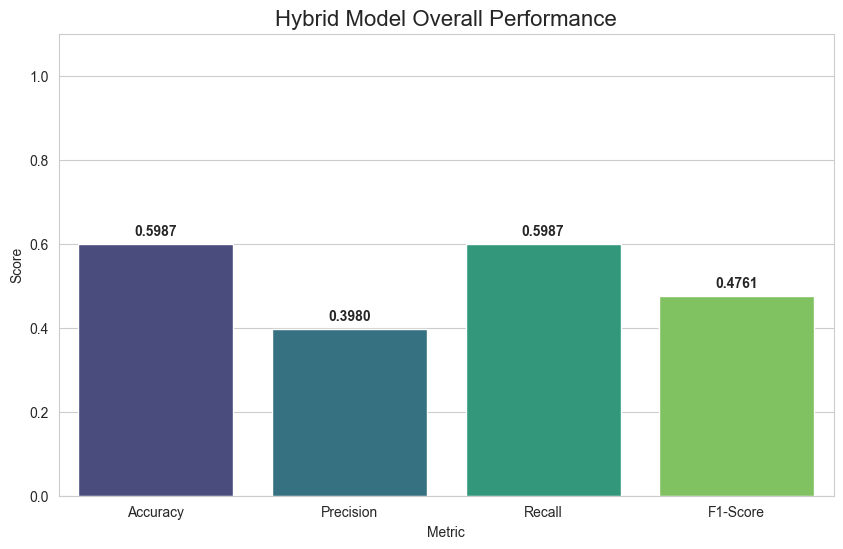

In [13]:
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
ax = sns.barplot(x='Metric', y='Score', data=metrics_df, palette='viridis')
plt.title('Hybrid Model Overall Performance', fontsize=16)
plt.ylim(0, 1.1)

for p in ax.patches:
    ax.annotate(format(p.get_height(), '.4f'), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', xytext=(0, 9), 
                textcoords='offset points', fontweight='bold')

plt.show()

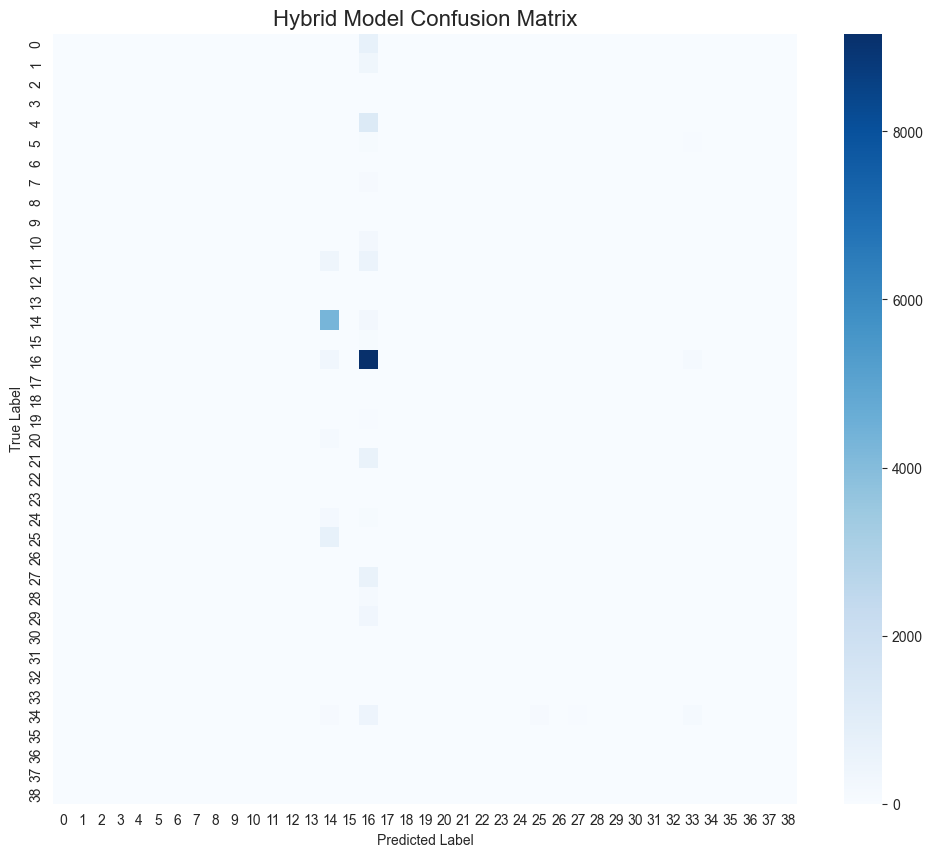

In [14]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=False, cmap='Blues')
plt.title('Hybrid Model Confusion Matrix', fontsize=16)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [15]:
joblib.dump(hybrid_model, 'hybrid_intrusion_model.joblib')
print("\nHybrid model saved successfully!")


Hybrid model saved successfully!
